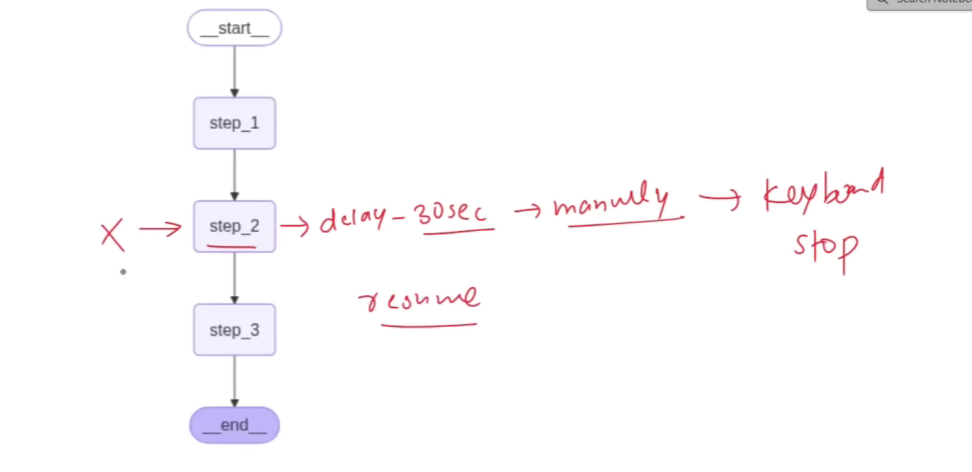

We will simulate node crash/workflow crash by implimenting a delay of 30 sec in step 2 and hitting Keyboard Interrupt. Then we will use persistence concept to restart our workflow from that checkpoint

In [32]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [33]:
# 1. Define the state
class CrashState(TypedDict):
    input : str
    step1: str
    step2: str
    step3: str

In [34]:
# 2. Define steps

def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    #time.sleep(30)  # Simulate long-running hang
    for _ in range(30):
        time.sleep(1)
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"step3": "done"}

In [35]:
# 3. Build the graph

builder = StateGraph(CrashState)

builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.add_edge(START, "step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)


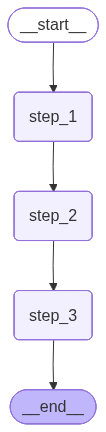

In [36]:
graph

In [37]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": "thread-1"}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [38]:
graph.get_state({"configurable": {"thread_id": "thread-1"}})

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb24-63c2-65ed-8001-7a3eccf91046'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-02-22T05:49:38.213826+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb24-63c1-61fb-8000-5da77dfe7429'}}, tasks=(PregelTask(id='04bf8af6-0e82-92a4-dab9-b80a01e84e20', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In the above state snapshot, you see its shows 'step1': 'done' and shows next is Step2, that means server crashed in Node 2 so it will run step2 when we re-run the workflow

In [39]:
list(graph.get_state_history({"configurable": {"thread_id": "thread-1"}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb24-63c2-65ed-8001-7a3eccf91046'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-02-22T05:49:38.213826+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb24-63c1-61fb-8000-5da77dfe7429'}}, tasks=(PregelTask(id='04bf8af6-0e82-92a4-dab9-b80a01e84e20', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step_1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb24-63c1-61fb-8000-5da77dfe7429'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-02-22T05:49:38.213316+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'ch

In [40]:
# 6. Re-run to show fault-tolerant resume -> I passed None in invoke which means i want
# to resume my workflow from the last stop/crash/interrupt
# Re-run for showing Fault Tolerance.
final_state = graph.invoke(None, config={"configurable": {"thread_id": "thread-1"}})
print("\n ✅ Final State:", final_state)

⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed

 ✅ Final State: {'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}


We see Step 1 was not shown, it directly started from step 2

In [41]:
graph.get_state({"configurable": {"thread_id": "thread-1"}})

StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb26-1349-620c-8003-dfe0b8f125d3'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-02-22T05:50:23.462647+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb26-1347-6e56-8002-60aa2c490c5d'}}, tasks=(), interrupts=())

In [42]:
list(graph.get_state_history({"configurable": {"thread_id": "thread-1"}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb26-1349-620c-8003-dfe0b8f125d3'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-02-22T05:50:23.462647+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb26-1347-6e56-8002-60aa2c490c5d'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb26-1347-6e56-8002-60aa2c490c5d'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-02-22T05:50:23.462136+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f10fb24-63c2-65ed-8001-7a3eccf91046'}}, tasks=(PregelTask(id='c76e669c-951d-089d

In the above snapshots, we see all the steps have executed